<a href="https://colab.research.google.com/github/vaishu0161/data_analytics-project/blob/main/DATA_ANALYICS_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
except ImportError:
    filename = '/content/seasonal_agriculture_performance_dataset (1).csv'

df = pd.read_csv(filename)
season_order = ['Kharif', 'Rabi', 'Zaid']
df.head()

Saving seasonal_agriculture_performance_dataset (1).csv to seasonal_agriculture_performance_dataset (1) (2).csv


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
# Dataset shape and structure

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3  

Top 5 rows of the dataset:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [6]:


print("Data types of each variable:")

display(
    pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null Count': df.notnull().sum().values,
        'Unique Values': df.nunique().values
    })
)

Data types of each variable:


,Column,Data Type,Non-Null Count,Unique Values
0,Farm_ID,object,4000,4000
1,State,object,4000,8
2,District,object,4000,10
3,Crop,object,4000,8
4,Season,object,4000,3
5,Farm_Area_Hectares,float64,4000,1370
6,Rainfall_mm,float64,3952,3256
7,Avg_Temperature_C,float64,4000,204
8,Humidity_pct,float64,4000,573
9,Sunlight_Hours_Day,float64,4000,71


In [8]:
# Missing values identified

missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': (missing / len(df)) * 100
})

display(
    missing_summary[
        missing_summary['Missing Values'] > 0
    ]
)

,Missing Values,Percentage (%)
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [9]:
# Missing values handled using season-wise median
# This preserves seasonal characteristics.

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:

    df[col] = df.groupby('Season')[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Missing values after treatment:")

print(
    df.isnull().sum()[
        df.isnull().sum() > 0
    ]
)

Missing values after treatment:
Series([], dtype: int64)


In [10]:
# Duplicate records identified and handled

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate records removed.")
else:
    print("No duplicate records found.")

print("Dataset shape after duplicate handling:", df.shape)

Number of duplicate records: 0
No duplicate records found.
Dataset shape after duplicate handling: (4000, 28)


In [11]:
# Descriptive statistical analysis

numeric_cols = df.select_dtypes(
    include=np.number
).columns

display(
    df[numeric_cols].describe().T.round(2)
)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,4000.0,600.71,288.43,80.00,370.42,581.00,836.12,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,4000.0,26.50,6.70,8.00,21.70,26.40,31.20,47.00
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [12]:
# Mean, median, standard deviation, minimum and maximum

descriptive_stats = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Std Dev': df[numeric_cols].std(),
    'Minimum': df[numeric_cols].min(),
    'Maximum': df[numeric_cols].max()
})

display(descriptive_stats.round(2))

,Mean,Median,Std Dev,Minimum,Maximum
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00
Rainfall_mm,600.71,581.00,288.43,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.50,26.40,6.70,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [13]:
# Outliers investigated using IQR method

outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    outlier_summary.append([
        col,
        Q1,
        Q3,
        IQR,
        lower,
        upper,
        outlier_count
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        'Variable',
        'Q1',
        'Q3',
        'IQR',
        'Lower Bound',
        'Upper Bound',
        'Outlier Count'
    ]
)

display(outlier_df.round(2))

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Farm_Area_Hectares,4.26,11.65,7.39,-6.83,22.74,0
1,Rainfall_mm,370.42,836.12,465.70,-328.12,1534.68,0
2,Avg_Temperature_C,23.90,29.60,5.70,15.35,38.15,2
3,Humidity_pct,54.78,71.90,17.13,29.09,97.59,6
4,Sunlight_Hours_Day,6.60,8.10,1.50,4.35,10.35,26
5,Soil_pH,6.26,7.14,0.88,4.94,8.46,0
6,Soil_Moisture_pct,21.70,31.20,9.50,7.45,45.45,5
7,Nitrogen_kg_ha,98.50,141.22,42.72,34.41,205.31,10
8,Phosphorus_kg_ha,46.20,69.40,23.20,11.40,104.20,16
9,Potassium_kg_ha,86.20,123.60,37.40,30.10,179.70,32


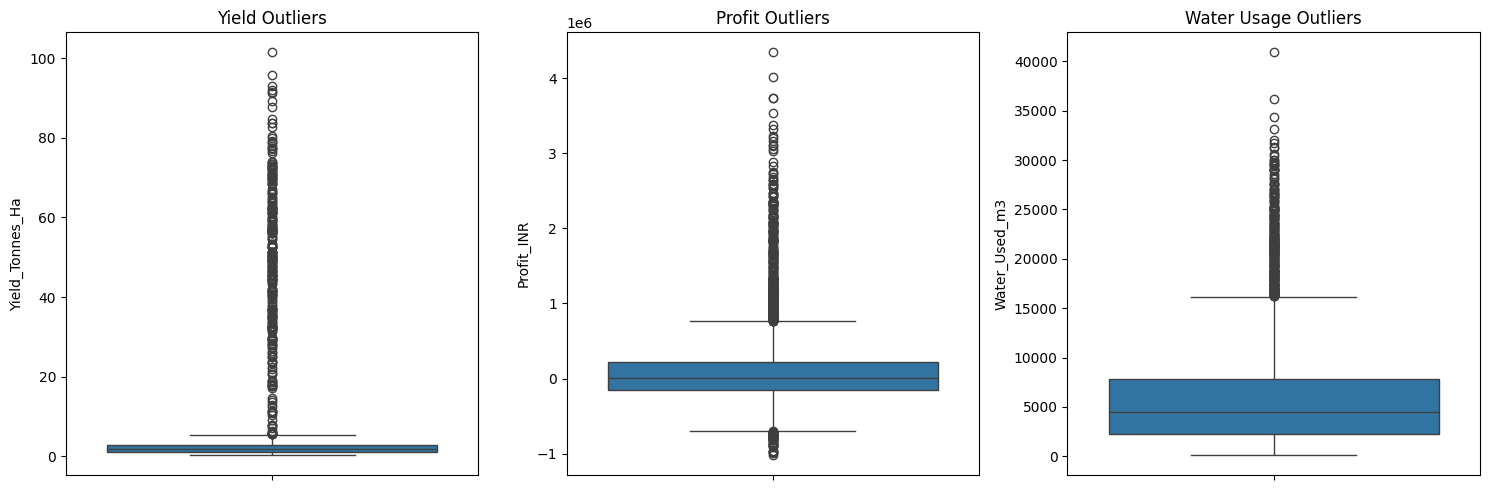

In [14]:
# Outlier visualization for important agricultural variables

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(
    data=df,
    y='Yield_Tonnes_Ha',
    ax=axes[0]
)

axes[0].set_title('Yield Outliers')


sns.boxplot(
    data=df,
    y='Profit_INR',
    ax=axes[1]
)

axes[1].set_title('Profit Outliers')


sns.boxplot(
    data=df,
    y='Water_Used_m3',
    ax=axes[2]
)

axes[2].set_title('Water Usage Outliers')

plt.tight_layout()
plt.show()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


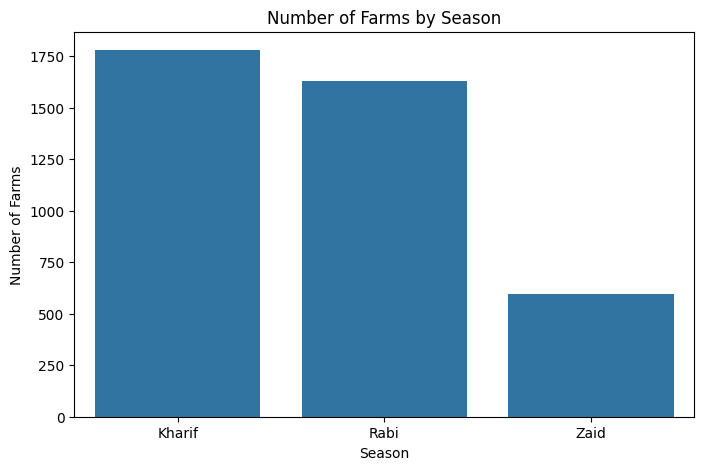

In [15]:
# Univariate analysis:
# Distribution of agricultural seasons

print(df['Season'].value_counts())

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Season',
    order=season_order
)

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.show()

,Number of Records
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


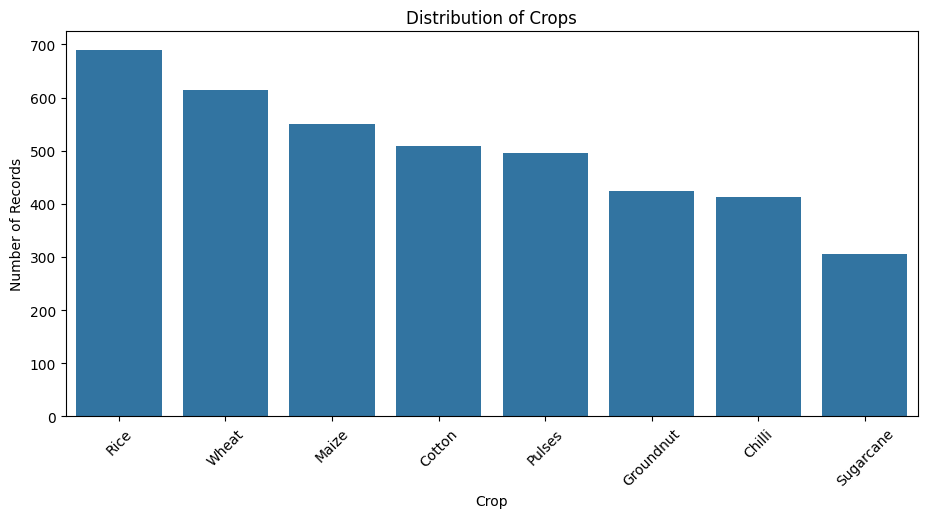

In [16]:
# Univariate analysis:
# Distribution of crops

crop_counts = df['Crop'].value_counts()

display(crop_counts.to_frame('Number of Records'))

plt.figure(figsize=(11, 5))

sns.countplot(
    data=df,
    x='Crop',
    order=crop_counts.index
)

plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Records')

plt.xticks(rotation=45)

plt.show()

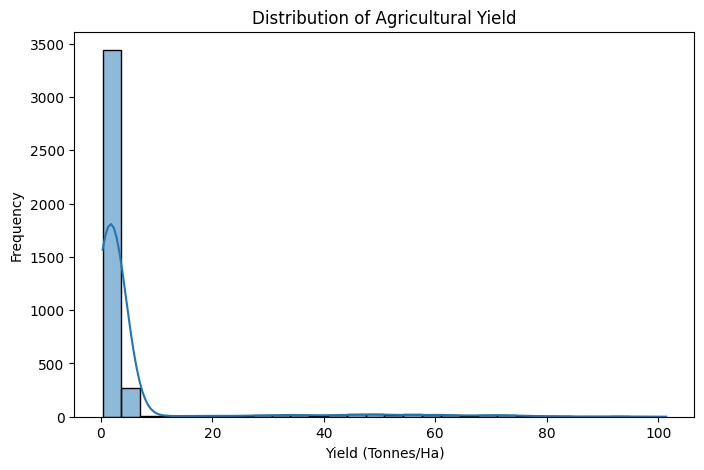

In [18]:
# Univariate analysis:
# Distribution of yield

plt.figure(figsize=(8, 5))

sns.histplot(
    df['Yield_Tonnes_Ha'],
    bins=30,
    kde=True
)

plt.title('Distribution of Agricultural Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')

plt.show()

In [19]:
# Q1/Q2/Q7:
# How does agricultural performance vary across seasons?

season_summary = (
    df.groupby('Season')[
        [
            'Yield_Tonnes_Ha',
            'Production_Tonnes',
            'Profit_INR',
            'Total_Cost_INR',
            'Revenue_INR'
        ]
    ]
    .mean()
    .reindex(season_order)
)

season_summary['Loss_Making_Pct'] = (
    df.groupby('Season')['Profit_INR']
    .apply(lambda x: (x < 0).mean() * 100)
    .reindex(season_order)
)

display(season_summary.round(2))

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Total_Cost_INR,Revenue_INR,Loss_Making_Pct
Season,,,,,,
Kharif,5.63,46.31,178914.65,531804.41,710719.06,42.21
Rabi,5.04,41.49,87689.47,513836.58,601526.05,51.14
Zaid,4.64,38.89,-24804.82,543976.73,519171.90,64.48


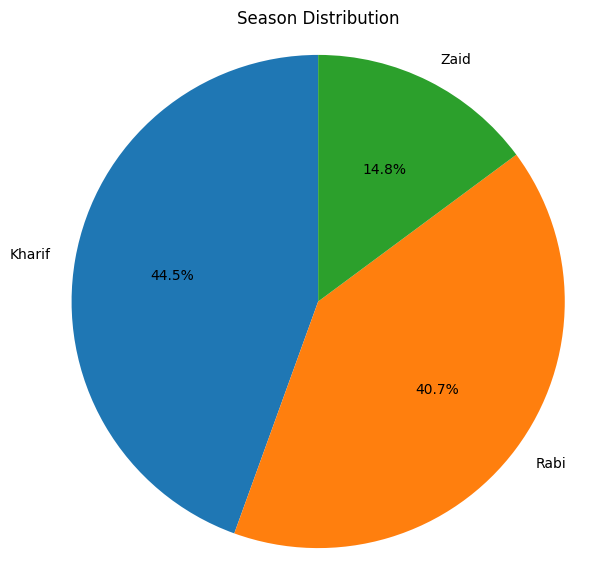

In [36]:
# Univariate Analysis - Season Distribution

season_counts = df['Season'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    season_counts.values,
    labels=season_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Season Distribution')

plt.axis('equal')

plt.show()

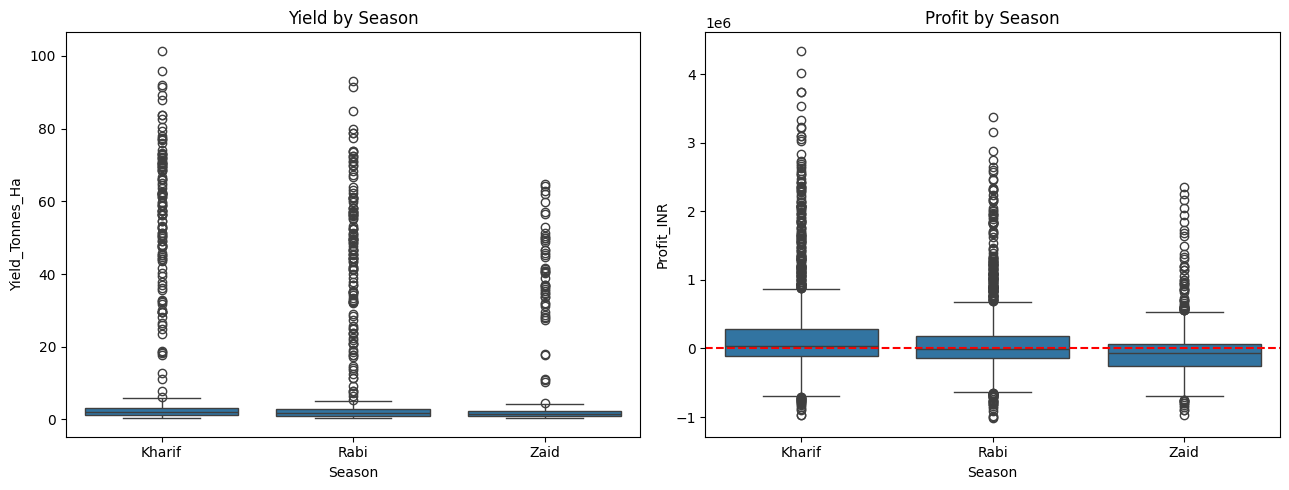

In [20]:
# Seasonal comparison using boxplots

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

sns.boxplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    order=season_order,
    ax=axes[0]
)

axes[0].set_title('Yield by Season')


sns.boxplot(
    data=df,
    x='Season',
    y='Profit_INR',
    order=season_order,
    ax=axes[1]
)

axes[1].axhline(
    0,
    color='red',
    linestyle='--'
)

axes[1].set_title('Profit by Season')

plt.tight_layout()
plt.show()

,Average Yield (Tonnes/Ha)
Crop,
Sugarcane,46.64
Maize,2.71
Rice,2.43
Wheat,2.11
Chilli,1.54
Groundnut,1.32
Cotton,1.23
Pulses,0.92


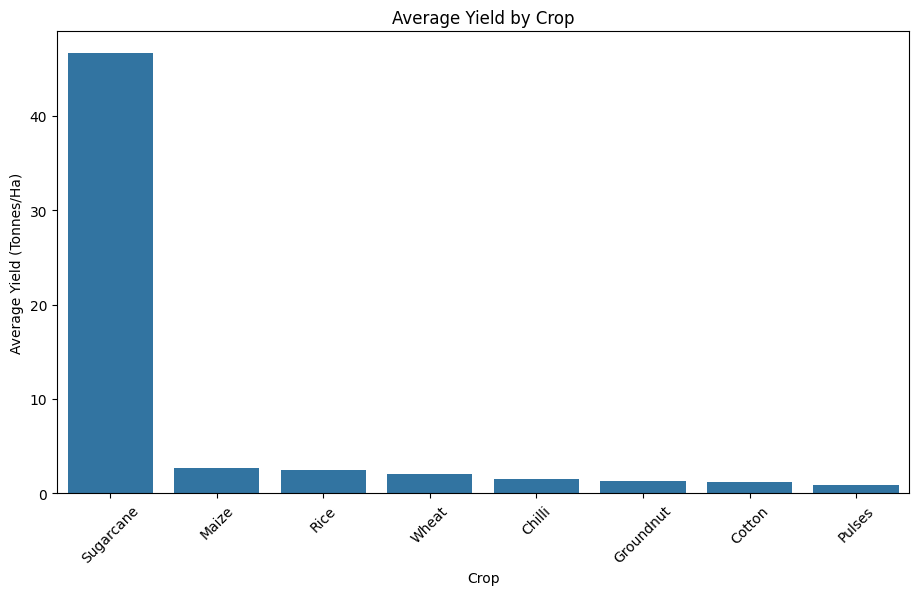

In [21]:
# Bivariate analysis:
# Which crops have higher average yield?

crop_yield = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

display(
    crop_yield.to_frame(
        'Average Yield (Tonnes/Ha)'
    ).round(2)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=crop_yield.index,
    y=crop_yield.values
)

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.xticks(rotation=45)

plt.show()

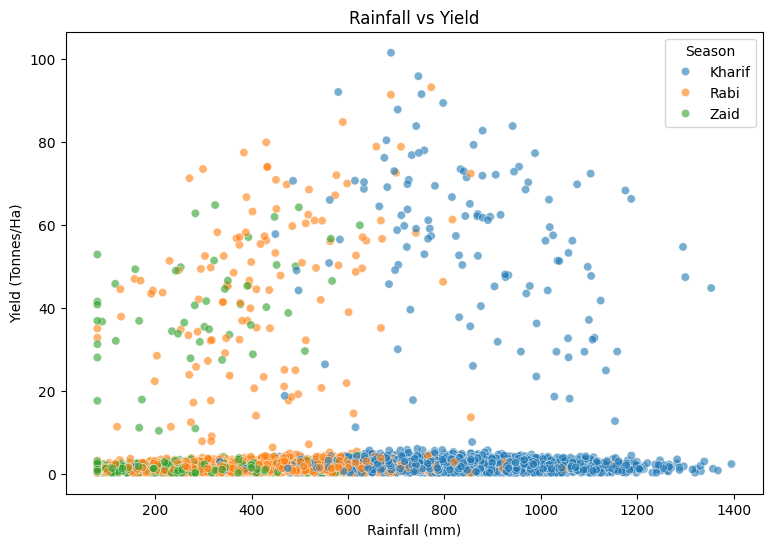

In [22]:
# Bivariate analysis:
# Relationship between rainfall and yield

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    hue_order=season_order,
    alpha=0.6
)

plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

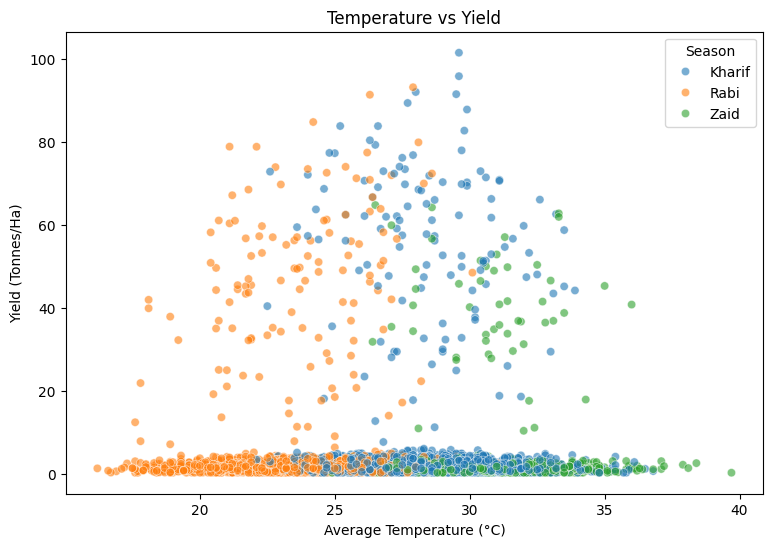

In [23]:
# Temperature vs yield

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season',
    hue_order=season_order,
    alpha=0.6
)

plt.title('Temperature vs Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

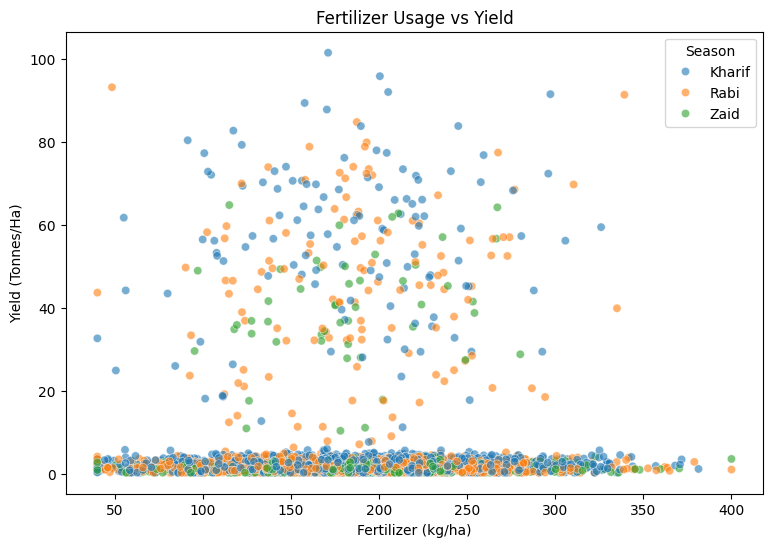

In [24]:
# Fertilizer usage vs yield

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season',
    hue_order=season_order,
    alpha=0.6
)

plt.title('Fertilizer Usage vs Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [25]:
# Q3/Q5:
# Which characteristics change between seasons?

resource_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Water_Used_m3',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Efficiency_t_per_1000m3'
]

resource_summary = (
    df.groupby('Season')[resource_cols]
    .mean()
    .reindex(season_order)
)

display(resource_summary.round(2))

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Efficiency_t_per_1000m3
Season,,,,,,,,
Kharif,852.11,28.45,71.81,31.20,6102.20,187.08,5.08,5.89
Rabi,435.94,23.49,57.89,24.05,5846.99,185.41,5.02,5.19
Zaid,299.12,31.04,52.01,19.17,6419.89,184.64,5.17,4.41


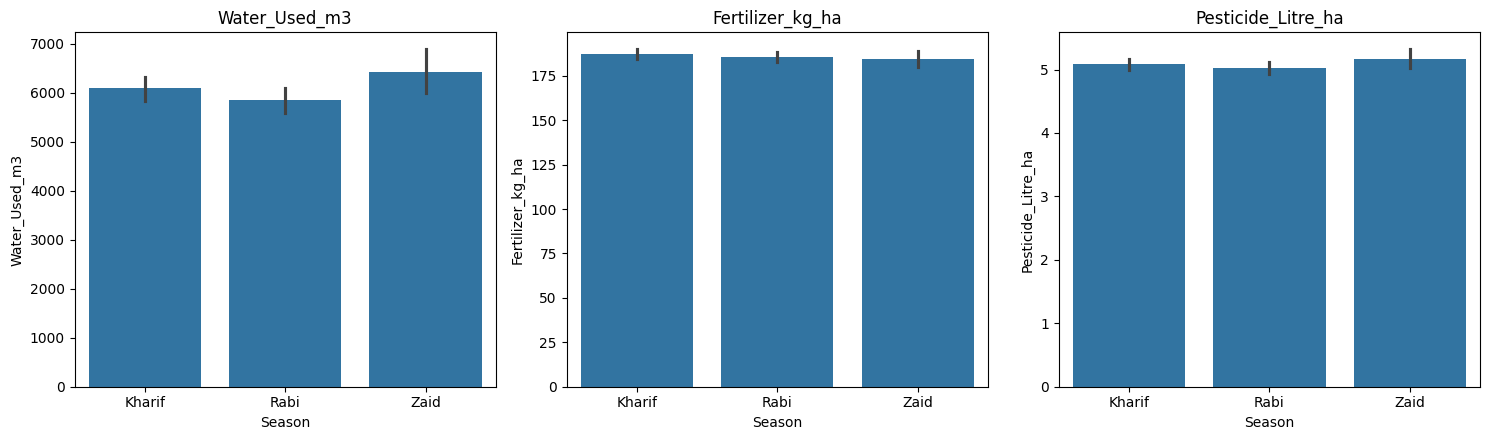

In [26]:
# Resource usage comparison across seasons

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5)
)

for ax, col in zip(
    axes,
    [
        'Water_Used_m3',
        'Fertilizer_kg_ha',
        'Pesticide_Litre_ha'
    ]
):

    sns.barplot(
        data=df,
        x='Season',
        y=col,
        order=season_order,
        estimator=np.mean,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

In [27]:
# Q6:
# Relationships between environmental conditions
# and agricultural performance

env_perf_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Disease_Pest_Risk_pct'
]

corr = df[env_perf_cols].corr()

display(corr.round(2))

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Yield_Tonnes_Ha,Profit_INR,Disease_Pest_Risk_pct
Rainfall_mm,1.00,0.20,0.53,0.52,0.02,0.03,0.11,0.62
Avg_Temperature_C,0.20,1.00,0.14,0.08,0.02,0.01,0.01,0.25
Humidity_pct,0.53,0.14,1.00,0.45,0.02,0.01,0.06,0.55
Soil_Moisture_pct,0.52,0.08,0.45,1.00,0.01,0.01,0.09,0.38
Fertilizer_kg_ha,0.02,0.02,0.02,0.01,1.00,-0.00,-0.07,0.02
Yield_Tonnes_Ha,0.03,0.01,0.01,0.01,-0.00,1.00,0.49,0.01
Profit_INR,0.11,0.01,0.06,0.09,-0.07,0.49,1.00,0.07
Disease_Pest_Risk_pct,0.62,0.25,0.55,0.38,0.02,0.01,0.07,1.00


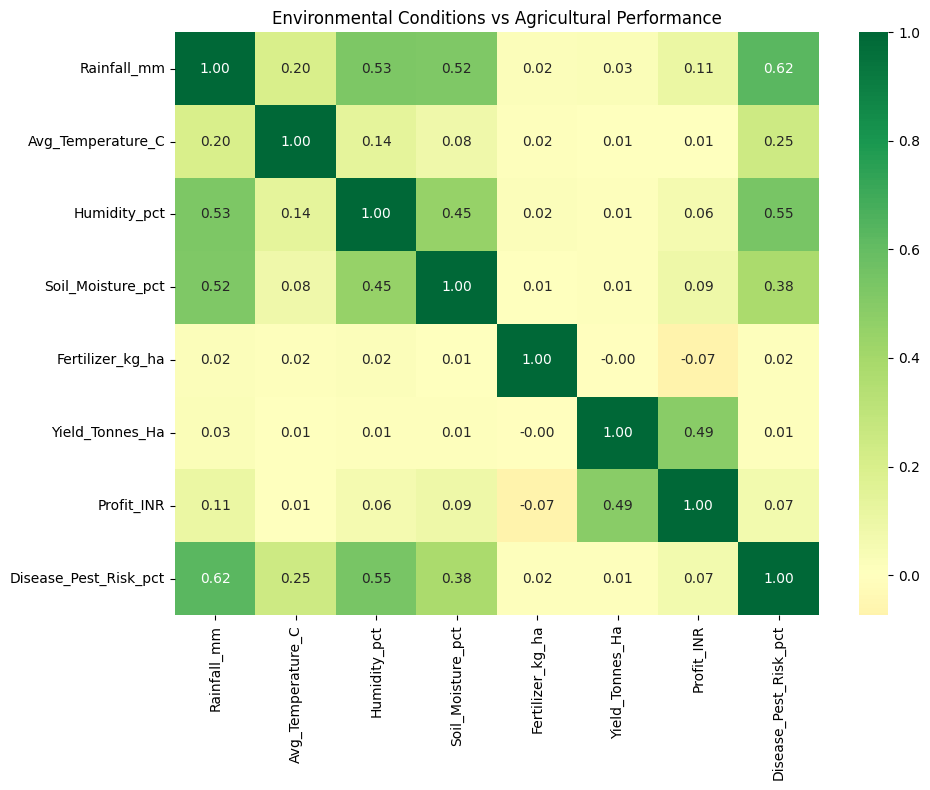

In [28]:
# Correlation heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0
)

plt.title(
    'Environmental Conditions vs Agricultural Performance'
)

plt.tight_layout()
plt.show()

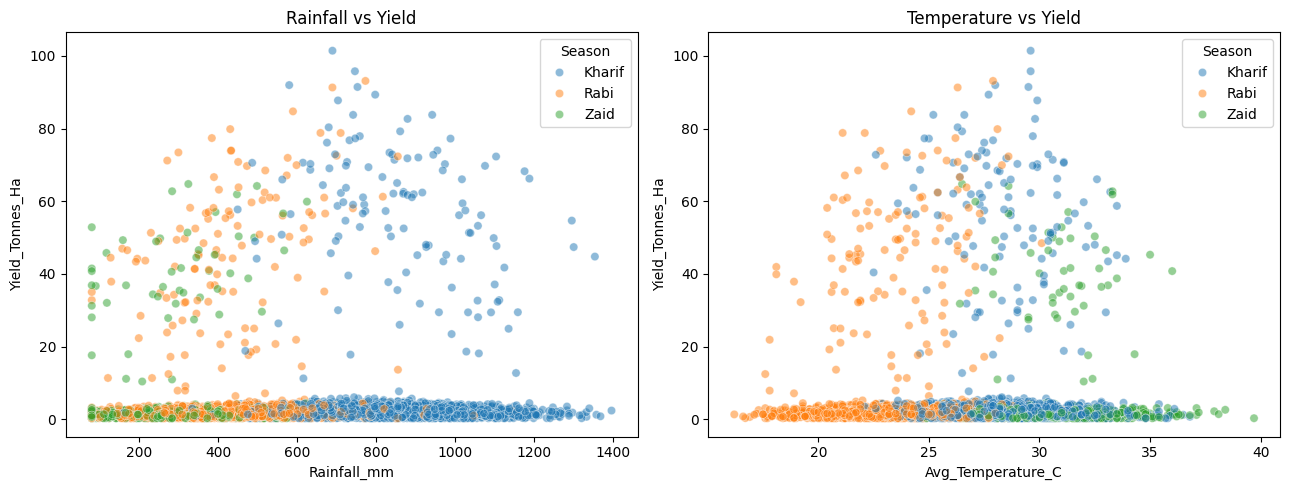

In [29]:
# Multivariate analysis:
# Rainfall and temperature in relation to yield

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    hue_order=season_order,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title('Rainfall vs Yield')


sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season',
    hue_order=season_order,
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title('Temperature vs Yield')

plt.tight_layout()
plt.show()

In [30]:
# Q8:
# Are seasonal patterns consistent across states?

pivot_state = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
).reindex(columns=season_order)

display(pivot_state.round(2))

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.44
Gujarat,6.34,5.44,4.06
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.47
Maharashtra,5.43,5.50,2.27
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


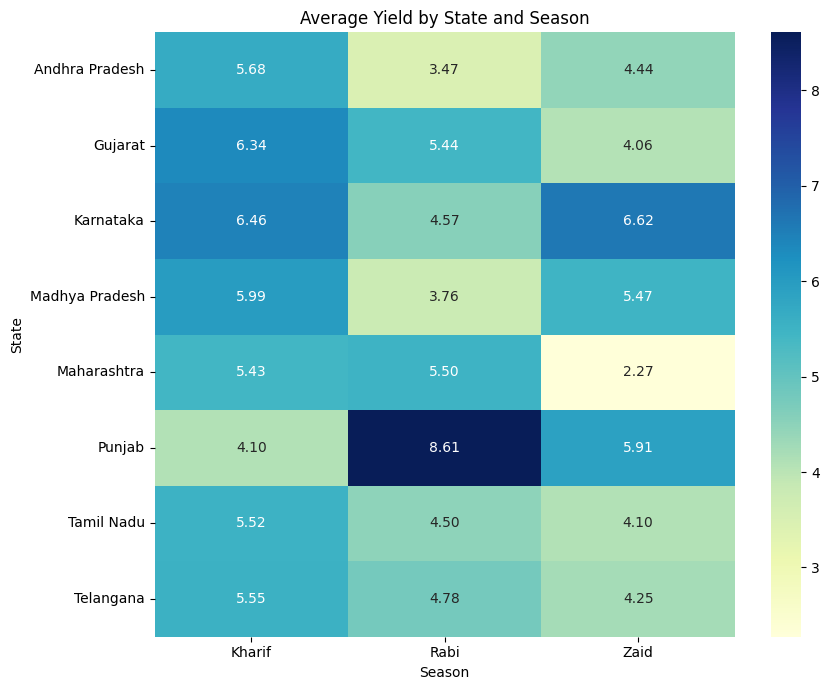

In [31]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    pivot_state,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Yield by State and Season')

plt.xlabel('Season')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [32]:
# Student-designed analysis 1:
# Which crop performs best in each season?

season_crop_yield = (
    df.groupby(
        ['Season', 'Crop']
    )['Yield_Tonnes_Ha']
    .mean()
    .reset_index()
)

best_crop_each_season = (
    season_crop_yield
    .loc[
        season_crop_yield
        .groupby('Season')['Yield_Tonnes_Ha']
        .idxmax()
    ]
)

print("Best performing crop in each season:")

display(
    best_crop_each_season.round(2)
)

Best performing crop in each season:


,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.46
14,Rabi,Sugarcane,43.28
22,Zaid,Sugarcane,38.42


In [39]:
# Student-designed analysis 2:
# Which crop-season combination gives the highest profit?

crop_season_profit = (
    df.groupby(
        ['Crop', 'Season']
    )['Profit_INR']
    .mean()
    .reset_index()
)

best_combination = crop_season_profit.loc[
    crop_season_profit['Profit_INR'].idxmax()
]

print("Most profitable crop-season combination:")

print("Crop:", best_combination['Crop'])
print("Season:", best_combination['Season'])
print(
    "Average Profit: ₹",
    round(best_combination['Profit_INR'], 2)
)

Most profitable crop-season combination:
Crop: Sugarcane
Season: Kharif
Average Profit: ₹ 1000790.81


Correlation between water efficiency and yield: 0.913


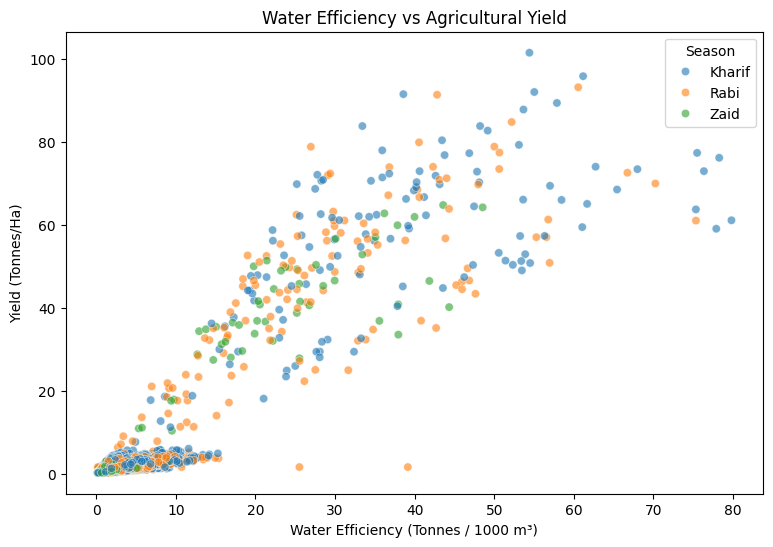

In [33]:
# Student-designed analysis 3:
# Does better water efficiency relate to higher yield?

water_yield_corr = df[
    [
        'Water_Efficiency_t_per_1000m3',
        'Yield_Tonnes_Ha'
    ]
].corr().iloc[0, 1]

print(
    "Correlation between water efficiency and yield:",
    round(water_yield_corr, 3)
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Water_Efficiency_t_per_1000m3',
    y='Yield_Tonnes_Ha',
    hue='Season',
    hue_order=season_order,
    alpha=0.6
)

plt.title(
    'Water Efficiency vs Agricultural Yield'
)

plt.xlabel(
    'Water Efficiency (Tonnes / 1000 m³)'
)

plt.ylabel(
    'Yield (Tonnes/Ha)'
)

plt.show()

In [34]:
# Q9:
# Are seasonal differences statistically significant?

def kruskal_test(metric):

    groups = [
        df[df['Season'] == s][metric].dropna()
        for s in season_order
    ]

    h, p = stats.kruskal(*groups)

    print(
        f"{metric}: H={h:.2f}, p={p:.4g}",
        "-> significant"
        if p < 0.05
        else "-> not significant"
    )


for metric in [
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3'
]:

    kruskal_test(metric)

Yield_Tonnes_Ha: H=70.17, p=5.804e-16 -> significant
Profit_INR: H=101.93, p=7.363e-23 -> significant
Water_Efficiency_t_per_1000m3: H=56.81, p=4.608e-13 -> significant


In [35]:
# Meaningful insights

print("=" * 70)
print("MEANINGFUL INSIGHTS")
print("=" * 70)


# Insight 1
best_yield_season = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .idxmax()
)

best_yield_value = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .max()
)

print(
    f"\n1. {best_yield_season} has the highest average yield "
    f"of {best_yield_value:.2f} tonnes/ha."
)


# Insight 2
lowest_yield_season = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .idxmin()
)

lowest_yield_value = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .min()
)

print(
    f"2. {lowest_yield_season} has the lowest average yield "
    f"of {lowest_yield_value:.2f} tonnes/ha."
)


# Insight 3
best_crop = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .idxmax()
)

best_crop_value = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .max()
)

print(
    f"3. {best_crop} has the highest average yield "
    f"at {best_crop_value:.2f} tonnes/ha."
)


# Insight 4
best_profit_season = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .idxmax()
)

best_profit_value = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .max()
)

print(
    f"4. {best_profit_season} has the highest average profit "
    f"of ₹{best_profit_value:,.2f}."
)


# Insight 5
best_water_season = (
    df.groupby('Season')
    ['Water_Efficiency_t_per_1000m3']
    .mean()
    .idxmax()
)

print(
    f"5. {best_water_season} has the highest average "
    f"water efficiency."
)


# Insight 6
highest_risk_season = (
    df.groupby('Season')
    ['Disease_Pest_Risk_pct']
    .mean()
    .idxmax()
)

highest_risk = (
    df.groupby('Season')
    ['Disease_Pest_Risk_pct']
    .mean()
    .max()
)

print(
    f"6. {highest_risk_season} has the highest average "
    f"disease/pest risk of {highest_risk:.2f}%."
)


# Insight 7
best_irrigation = (
    df.groupby('Irrigation_Method')
    ['Yield_Tonnes_Ha']
    .mean()
    .idxmax()
)

print(
    f"7. {best_irrigation} irrigation has the highest "
    f"average yield."
)


# Insight 8
best_state = (
    df.groupby('State')['Profit_INR']
    .mean()
    .idxmax()
)

print(
    f"8. {best_state} has the highest average profit "
    f"among the states."
)


# Insight 9
yield_corr = (
    df[numeric_cols]
    .corr()['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(
        key=abs,
        ascending=False
    )
)

strongest_variable = yield_corr.index[0]
strongest_value = yield_corr.iloc[0]

print(
    f"9. {strongest_variable} has the strongest "
    f"correlation with yield: {strongest_value:.3f}."
)


# Insight 10
print(
    f"10. The dataset contains {len(df):,} agricultural "
    f"records across {df['State'].nunique()} states, "
    f"{df['Crop'].nunique()} crops and "
    f"{df['Season'].nunique()} seasons."
)

MEANINGFUL INSIGHTS

1. Kharif has the highest average yield of 5.63 tonnes/ha.
2. Zaid has the lowest average yield of 4.64 tonnes/ha.
3. Sugarcane has the highest average yield at 46.64 tonnes/ha.
4. Kharif has the highest average profit of ₹178,914.65.
5. Kharif has the highest average water efficiency.
6. Kharif has the highest average disease/pest risk of 54.47%.
7. Drip irrigation has the highest average yield.
8. Punjab has the highest average profit among the states.
9. Water_Efficiency_t_per_1000m3 has the strongest correlation with yield: 0.913.
10. The dataset contains 4,000 agricultural records across 8 states, 8 crops and 3 seasons.


In [ ]:
## Evidence-Based Recommendations

1. Seasonal crop planning should consider the season with the
   highest observed average yield.

2. Crops showing consistently high yields should be prioritized
   where soil and climatic conditions are suitable.

3. Efficient irrigation practices should be encouraged to improve
   productivity while reducing unnecessary water consumption.

4. Additional pest and disease monitoring should be carried out
   during seasons showing higher disease/pest risk.

5. Fertilizer and pesticide application should be optimized based
   on observed relationships with yield rather than excessive use.

6. Farmers should consider both yield and profit when selecting
   crops because the crop with the highest yield may not always
   provide the highest profit.

7. Water efficiency should be considered along with productivity
   when evaluating irrigation practices.

8. High-performing states or regions can be studied to identify
   agricultural practices that may be adaptable to other regions.

In [ ]:
## Limitations

1. The analysis is limited to the variables available in the
   provided dataset.

2. The dataset represents observed agricultural conditions and
   may not represent all farming regions.

3. Correlation between variables does not prove causation.

4. Missing values were handled using median-based imputation,
   which may slightly influence the results.

5. Outliers were identified using the IQR method, but they were
   not automatically removed because they may represent genuine
   agricultural observations.

6. Weather extremes, market changes, government policies and
   unexpected pest outbreaks may influence agricultural outcomes
   but may not be fully captured in the dataset.

7. Historical seasonal performance cannot guarantee future
   agricultural performance.

8. The results should therefore be interpreted together with
   agricultural domain knowledge.

In [ ]:
## Final Conclusion

The Seasonal Agriculture Performance dataset was analyzed to
understand agricultural performance across Kharif, Rabi and Zaid
seasons.

The analysis included data cleaning, descriptive statistics,
univariate analysis, bivariate analysis, multivariate analysis,
correlation analysis and seasonal comparisons.

The study examined important agricultural factors such as
rainfall, temperature, soil moisture, fertilizer usage,
irrigation, water efficiency, yield, production, revenue,
profit and disease/pest risk.

The student-designed analyses further explored crop performance
across seasons, crop-season profitability and the relationship
between water efficiency and yield.

The findings provide useful evidence for seasonal crop planning,
resource management, irrigation decisions and profitability
optimization.

Overall, the analysis demonstrates that data-driven agricultural
analysis can support better and more sustainable farming
decisions. However, the results should be combined with local
climatic, soil and economic knowledge before making real-world
decisions.